<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/PLN/261554_ClasificacionTexto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Autor: Juan Francisco Gámez Cortés.
Matricula: 261554 Abril de 2026

Materia: Procesamiento de Lenguaje Natural

Ejercicios: Clasificación de textos

In [1]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
#from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud
from nltk import word_tokenize, pos_tag

import string
from collections import Counter
import pandas as pd
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)

import warnings

warnings.filterwarnings("ignore")

In [3]:
# -- Descargas de NLTK --
for pkg in ['punkt', 'stopwords', 'wordnet', 'omw-1.4',
            'averaged_perceptron_tagger', 'punkt_tab',
            'averaged_perceptron_tagger_eng']:
    nltk.download(pkg, quiet=True)

# -- Variables --
STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

In [4]:
def get_wordnet_pos(treebank_tag):
    """Mapea el POS tag de NLTK al formato que acepta
    WordNetLemmatizer, permitiendo lematizar correctamente
    verbos, adjetivos y adverbios."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # valor por defecto

def readDataset(filename):
    """Carga el CSV y muestra información básica."""
    df = pd.read_csv(filename)
    print("=== Primeras filas ===")
    print(df.head())
    print("\n=== Dimensiones del dataset ===")
    print(df.shape)
    print("\n=== Valores nulos ===")
    print(df.isnull().sum())
    print("\n=== Distribución de sentimiento ===")
    print(df['sentimento'].value_counts())
    return df

def preprocess(text):
    """Pipeline con LEMMATIZACIÓN (no stemming):
       1. Elimina etiquetas HTML  (<br />, etc.)
       2. Elimina caracteres no alfabéticos
       3. Minúsculas
       4. Tokeniza con word_tokenize
       5. POS tagging para lemmatización
       6. Elimina stopwords y palabras cortas (≤2 chars)
       7. Lematiza con POS (VERB/ADJ/NOUN/ADV)
    """
    text = re.sub(r'<.*?>',     ' ', str(text))  # 1. HTML
    text = re.sub(r'[^a-zA-Z]', ' ', text)        # 2. solo letras
    text = text.lower()                            # 3. minúsculas
    tokens   = word_tokenize(text)                 # 4. tokenizar
    pos_tags = pos_tag(tokens)                     # 5. POS tagging
    tokens   = [
        LEMMATIZER.lemmatize(word, pos=get_wordnet_pos(tag))
        for word, tag in pos_tags
        if word not in STOP_WORDS and len(word) > 2  # 6 & 7
    ]
    return ' '.join(tokens)


def preprocess_dataset(df):
    print("\n🔧 Preprocesando texto…")
    before = len(df)
    df.dropna(subset=['review', 'sentimento'], inplace=True)
    df.drop_duplicates(subset=['review'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"   Filas eliminadas (nulos/duplicados): {before - len(df)}")
    print(f"   Filas finales                      : {len(df)}")

    df['review_len_raw'] = df['review'].astype(str).apply(len)
    print("   Aplicando limpieza…")
    df['cleaned']          = df['review'].astype(str).apply(preprocess)
    df['review_len_clean'] = df['cleaned'].apply(len)

    print("\n  Ejemplos de preprocesamiento (antes → después):")
    print(f"   {'#':<4} {'ANTES (fragmento 60 chars)':<62} {'DESPUÉS'}")
    print("   " + "-"*110)
    for i in range(min(5, len(df))):
        raw = df['review'].iloc[i][:60].replace('\n', ' ')
        cln = df['cleaned'].iloc[i][:60]
        print(f"   {i:<4} {raw:<62} {cln}")
    return df


# ─ EDA -
def run_eda(df):
    print("\n Análisis Exploratorio de Datos (EDA)…")
    label_map = {0: 'Negativo', 1: 'Positivo'}
    df['label'] = df['sentimento'].map(label_map)

    # 1. Distribución de clases
    fig, ax = plt.subplots(figsize=(6, 4))
    counts  = df['label'].value_counts()
    bars    = ax.bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'])
    ax.set_title('Distribución de Clases', fontsize=13)
    ax.set_xlabel('Sentimiento'); ax.set_ylabel('Cantidad')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 5,
                str(v), ha='center', fontweight='bold')
    plt.tight_layout(); plt.show()

    # 2. Longitud antes vs después
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, col, title in zip(axes,
        ['review_len_raw', 'review_len_clean'],
        ['Longitud Original (caracteres)',
         'Longitud tras Preprocesamiento (caracteres)']):
        sns.histplot(data=df, x=col, hue='label', bins=50, kde=True,
                     palette={'Negativo':'#e74c3c','Positivo':'#2ecc71'}, ax=ax)
        ax.set_title(title); ax.set_xlabel('Longitud'); ax.set_ylabel('Frecuencia')
    plt.tight_layout(); plt.show()

    # 3. Longitud promedio por clase
    avg = df.groupby('label')[['review_len_raw','review_len_clean']].mean().round(1)
    print("\n   Longitud promedio por clase:"); print(avg.to_string())
    avg.plot(kind='bar', figsize=(7, 4), color=['#3498db','#f39c12'], rot=0)
    plt.title('Longitud Promedio de Reseña por Clase')
    plt.ylabel('Caracteres'); plt.legend(['Original','Preprocesada'])
    plt.tight_layout(); plt.show()

    # 4. Top 20 palabras globales
    all_words = ' '.join(df['cleaned']).split()
    common20  = Counter(all_words).most_common(20)
    plt.figure(figsize=(12, 5))
    sns.barplot(x=[c[1] for c in common20], y=[c[0] for c in common20],
                palette='Blues_d')
    plt.title('Top 20 Palabras Más Frecuentes (post-preprocesamiento)')
    plt.xlabel('Frecuencia'); plt.ylabel('Palabra')
    plt.tight_layout(); plt.show()

    # 5. Top 15 palabras por clase
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (val, name), pal in zip(axes, label_map.items(), ['Reds_d','Greens_d']):
        words = ' '.join(df[df['sentimento'] == val]['cleaned']).split()
        freq  = Counter(words).most_common(15)
        sns.barplot(x=[f[1] for f in freq], y=[f[0] for f in freq],
                    palette=pal, ax=ax)
        ax.set_title(f'Top 15 Palabras – Reseñas {name}s')
        ax.set_xlabel('Frecuencia'); ax.set_ylabel('Palabra')
    plt.tight_layout(); plt.show()

    # 6. WordClouds por clase
    for val, name in label_map.items():
        text = ' '.join(df[df['sentimento'] == val]['cleaned'])
        wc   = WordCloud(width=800, height=400, background_color='white',
                         colormap='Reds' if val == 0 else 'Greens').generate(text)
        plt.figure(figsize=(10, 4))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'WordCloud – Reseñas {name}s', fontsize=14)
        plt.tight_layout(); plt.show()


# ─Gráficas de evaluación ─
def plot_confusion_matrix(y_true, y_pred, model_name, vec_name, labels):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
    ax.set_title(f'Matriz de Confusión\n{model_name} | {vec_name}')
    plt.tight_layout(); plt.show()


def plot_roc_curve(y_true, y_prob, model_name, vec_name, auc_score):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'AUC = {auc_score:.4f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    plt.xlabel('Tasa Falsos Positivos')
    plt.ylabel('Tasa Verdaderos Positivos')
    plt.title(f'Curva ROC\n{model_name} | {vec_name}')
    plt.legend(loc='lower right')
    plt.tight_layout(); plt.show()


# -Entrenar y evaluar ─
def evaluate_model(clf, X_train, X_test, y_train, y_test,
                   model_name, vec_name, label_names):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    acc    = accuracy_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred,
                                   target_names=label_names,
                                   output_dict=True)
    print(f"\n{'='*58}")
    print(f"  Modelo     : {model_name}")
    print(f"  Vectorizer : {vec_name}")
    print(f"{'='*58}")
    print(f"  Accuracy   : {acc:.4f}  |  AUC-ROC: {auc:.4f}")
    print("\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_names))

    plot_confusion_matrix(y_test, y_pred, model_name, vec_name, label_names)
    plot_roc_curve(y_test, y_prob, model_name, vec_name, auc)

    return {
        'Vectorizer'      : vec_name,
        'Modelo'          : model_name,
        'Accuracy'        : round(acc, 4),
        'AUC-ROC'         : round(auc, 4),
        'F1 (Negativo)'   : round(report[label_names[0]]['f1-score'], 4),
        'F1 (Positivo)'   : round(report[label_names[1]]['f1-score'], 4),
        'F1 Macro Avg'    : round(report['macro avg']['f1-score'], 4),
        'Precision Macro' : round(report['macro avg']['precision'], 4),
        'Recall Macro'    : round(report['macro avg']['recall'], 4),
    }

## Actividad
•	Utilizar el dataset IMDB Reviews.csv, el cual contiene dos clases en la columna ‘Sentimiento’: 1 indica un sentimiento positivo y 0 uno negativo. NOTA: Los comentarios están en inglés.

•	Realizar el preprocesamiento adecuado con respecto a lo que identifiques en el dataset.


In [5]:
# 1. Cargar
FILENAME = '/content/drive/MyDrive/PLN/IMDB Reviews.csv'
df = readDataset(FILENAME)

# 2. Preprocesar
df = preprocess_dataset(df)

=== Primeras filas ===
                                              review  sentimento
0  One of the other reviewers has mentioned that ...           1
1  A wonderful little production. <br /><br />The...           1
2  I thought this was a wonderful way to spend ti...           1
3  Basically there's a family where a little boy ...           0
4  Petter Mattei's "Love in the Time of Money" is...           1

=== Dimensiones del dataset ===
(50000, 2)

=== Valores nulos ===
review        0
sentimento    0
dtype: int64

=== Distribución de sentimiento ===
sentimento
1    25000
0    25000
Name: count, dtype: int64

🔧 Preprocesando texto…
   Filas eliminadas (nulos/duplicados): 418
   Filas finales                      : 49582
   Aplicando limpieza…

  Ejemplos de preprocesamiento (antes → después):
   #    ANTES (fragmento 60 chars)                                     DESPUÉS
   -------------------------------------------------------------------------------------------------------------

•	Realizar un análisis exploratorio de datos.


 Análisis Exploratorio de Datos (EDA)…


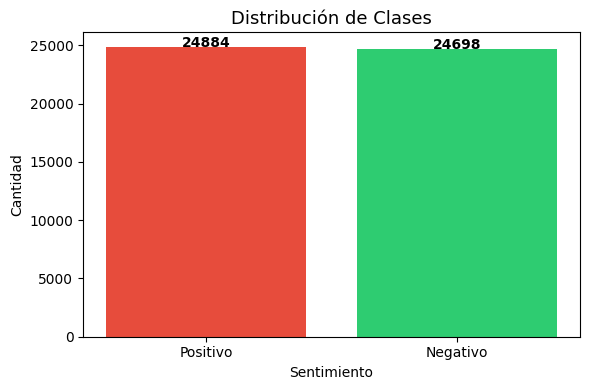

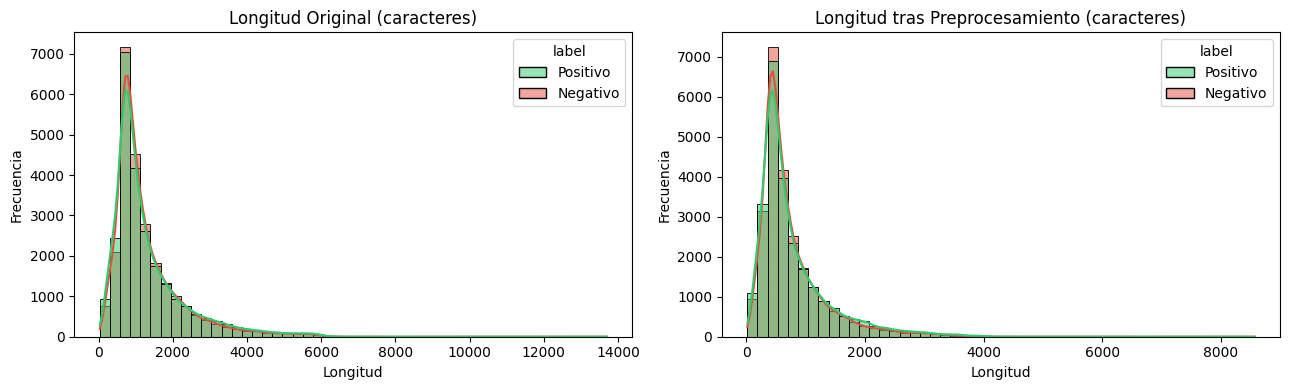


   Longitud promedio por clase:
          review_len_raw  review_len_clean
label                                     
Negativo          1294.7             754.0
Positivo          1326.3             791.9


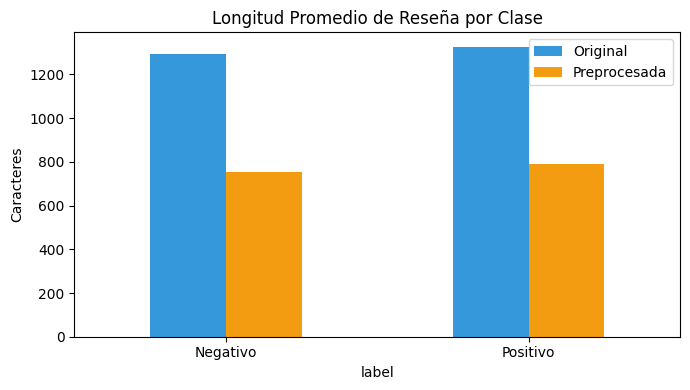

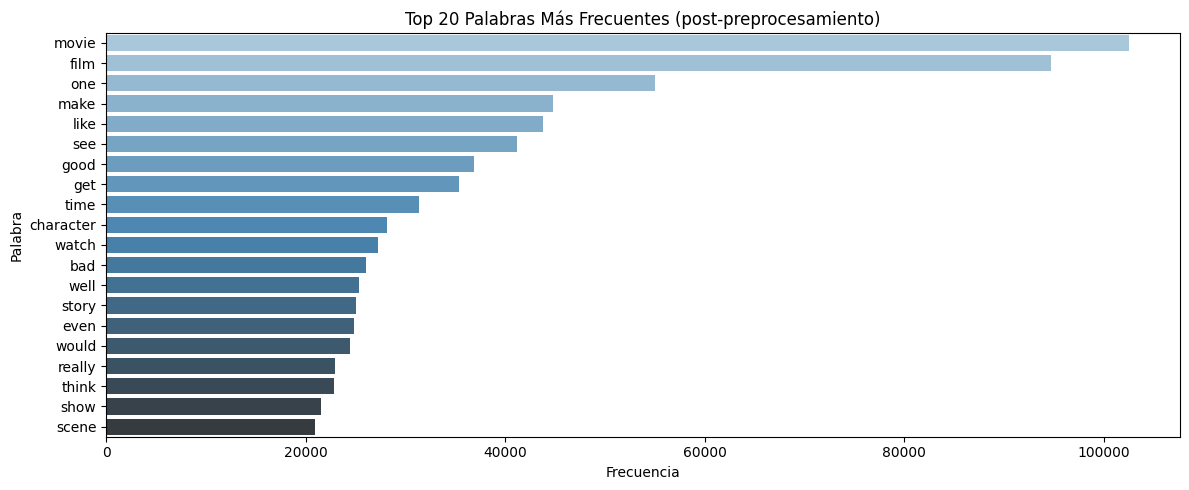

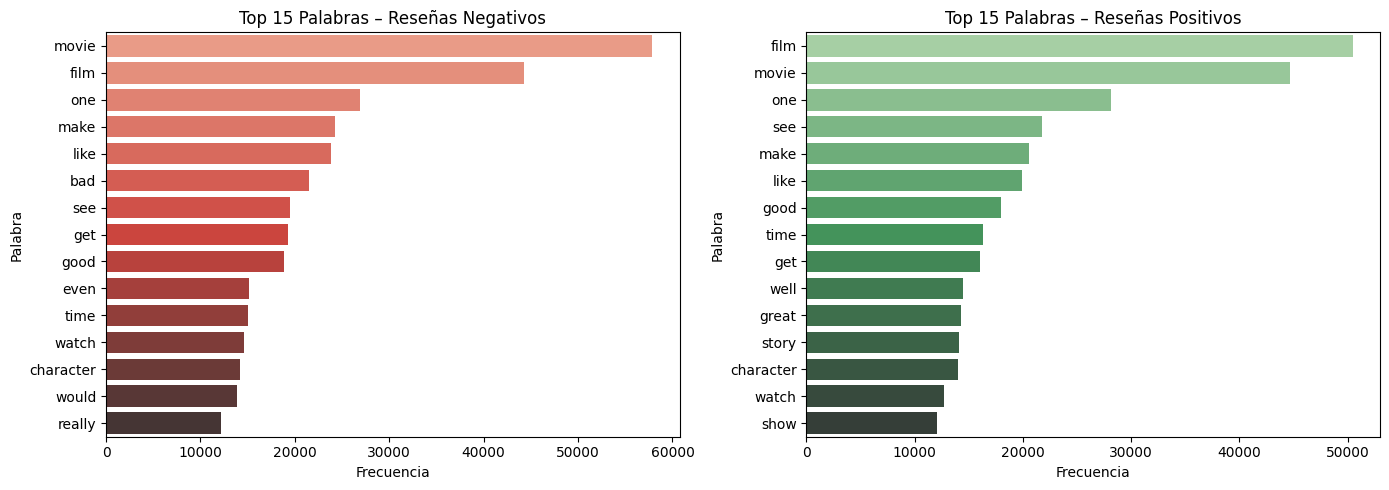

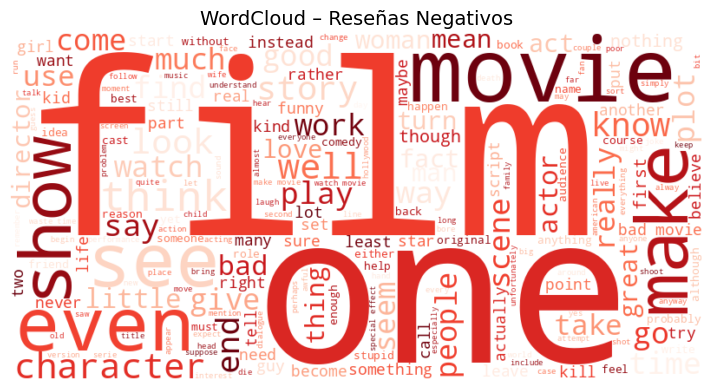

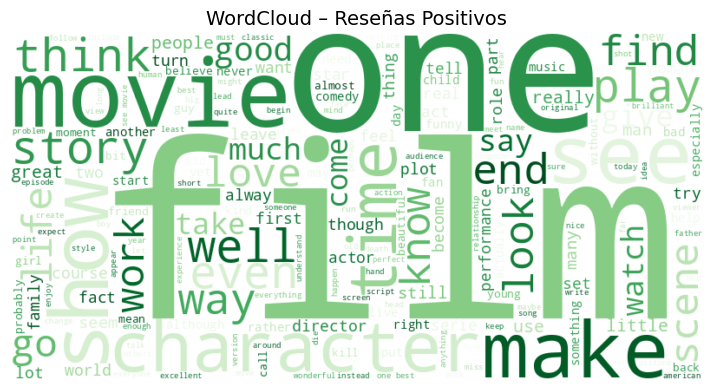

In [6]:
# 3. EDA
run_eda(df)

•	Utilizar Bag of Words y TF-IDF para transformar los comentarios que están en la columna ‘Review’ a vectores.

•	Utiliza una partición (train_test_split) 80-20 para los conjuntos train y test.


In [8]:
# 4. Preparar X, Y
X_raw       = df['cleaned'].values
Y           = df['sentimento'].values
label_names = ['Negativo', 'Positivo']

# 5. Train/Test split 80-20 estratificado
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, Y, test_size=0.20, random_state=42, stratify=Y
)
print(f"\n Train: {len(X_train_raw)} | Test: {len(X_test_raw)}")
print(f"   Distribución train: {Counter(y_train)}")
print(f"   Distribución test : {Counter(y_test)}")




 Train: 39665 | Test: 9917
   Distribución train: Counter({np.int64(1): 19907, np.int64(0): 19758})
   Distribución test : Counter({np.int64(1): 4977, np.int64(0): 4940})


•	Entrenar los modelos Multinomial Naive Bayes, SVM, Random Forest, kNN y Logistic Regression

•	Mostrar la matriz de confusión.

•	Aplicar las métricas Precision, Recall, F1-Score (por cada una de las clases), Accuracy y AUC-ROC.




##############################################################
#  VECTORIZADOR: BoW (CountVectorizer)
##############################################################
   Dimensión train: (39665, 10000)
   Dimensión test : (9917, 10000)

  Modelo     : Multinomial NB
  Vectorizer : BoW (CountVectorizer)
  Accuracy   : 0.8485  |  AUC-ROC: 0.9160

  Classification Report:
              precision    recall  f1-score   support

    Negativo       0.84      0.86      0.85      4940
    Positivo       0.86      0.84      0.85      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



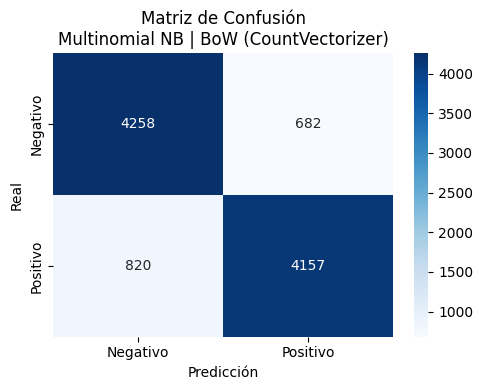

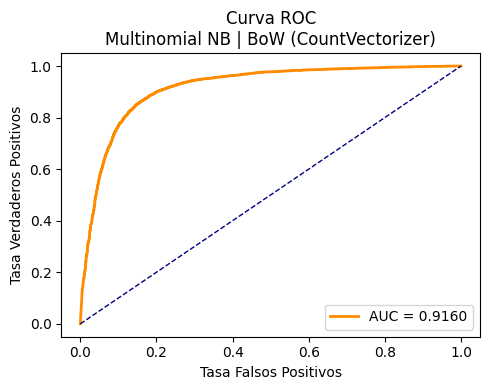


  Modelo     : SVM (LinearSVC)
  Vectorizer : BoW (CountVectorizer)
  Accuracy   : 0.8573  |  AUC-ROC: 0.9320

  Classification Report:
              precision    recall  f1-score   support

    Negativo       0.86      0.85      0.86      4940
    Positivo       0.85      0.87      0.86      4977

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



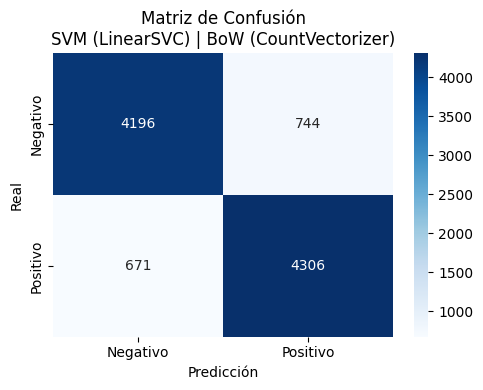

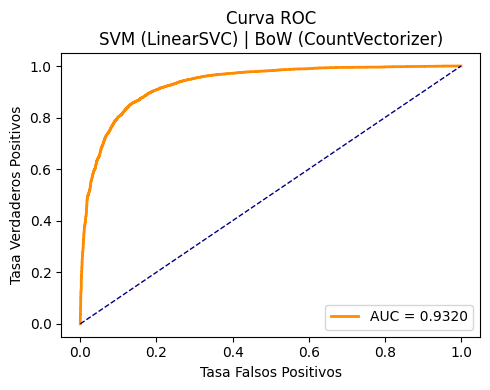


  Modelo     : Random Forest
  Vectorizer : BoW (CountVectorizer)
  Accuracy   : 0.8483  |  AUC-ROC: 0.9244

  Classification Report:
              precision    recall  f1-score   support

    Negativo       0.84      0.85      0.85      4940
    Positivo       0.85      0.84      0.85      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



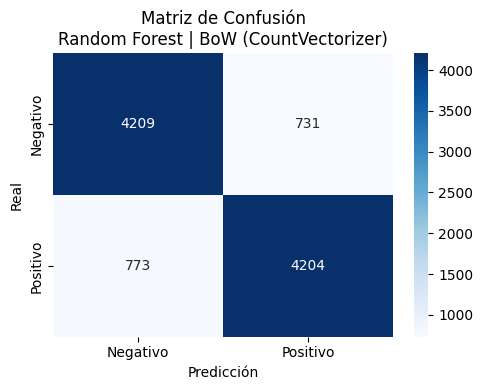

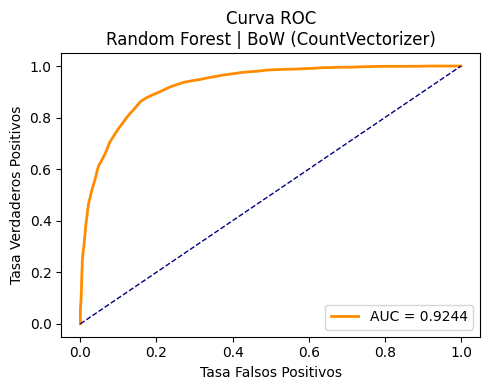


  Modelo     : kNN (k=5)
  Vectorizer : BoW (CountVectorizer)
  Accuracy   : 0.6504  |  AUC-ROC: 0.6967

  Classification Report:
              precision    recall  f1-score   support

    Negativo       0.65      0.64      0.65      4940
    Positivo       0.65      0.66      0.65      4977

    accuracy                           0.65      9917
   macro avg       0.65      0.65      0.65      9917
weighted avg       0.65      0.65      0.65      9917



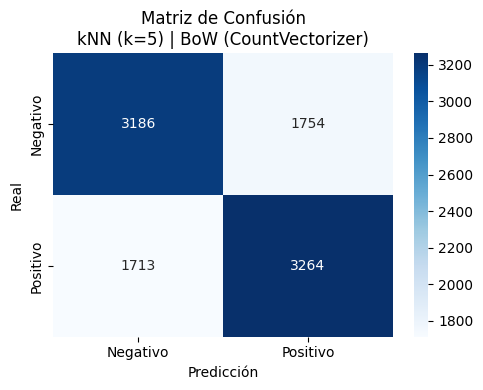

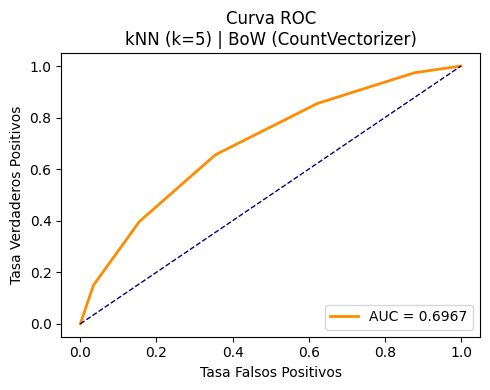


  Modelo     : Logistic Regression
  Vectorizer : BoW (CountVectorizer)
  Accuracy   : 0.8721  |  AUC-ROC: 0.9402

  Classification Report:
              precision    recall  f1-score   support

    Negativo       0.87      0.87      0.87      4940
    Positivo       0.87      0.88      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



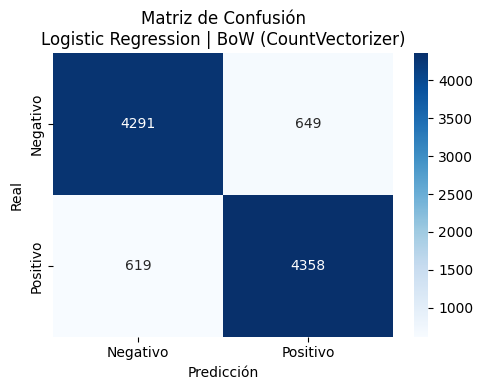

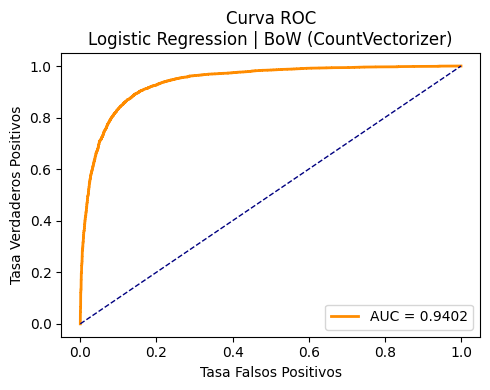



##############################################################
#  VECTORIZADOR: TF-IDF
##############################################################
   Dimensión train: (39665, 10000)
   Dimensión test : (9917, 10000)

  Modelo     : Multinomial NB
  Vectorizer : TF-IDF
  Accuracy   : 0.8674  |  AUC-ROC: 0.9387

  Classification Report:
              precision    recall  f1-score   support

    Negativo       0.88      0.85      0.87      4940
    Positivo       0.86      0.88      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



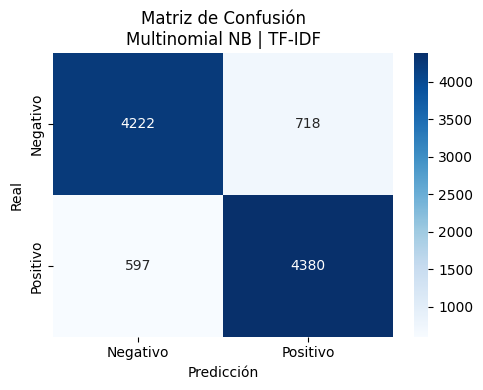

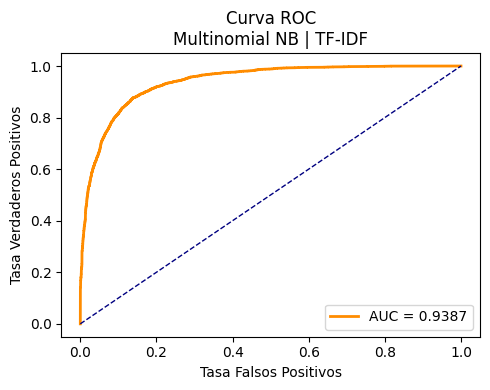


  Modelo     : SVM (LinearSVC)
  Vectorizer : TF-IDF
  Accuracy   : 0.8926  |  AUC-ROC: 0.9591

  Classification Report:
              precision    recall  f1-score   support

    Negativo       0.89      0.89      0.89      4940
    Positivo       0.89      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



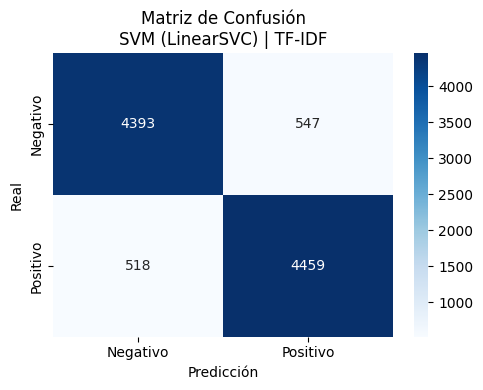

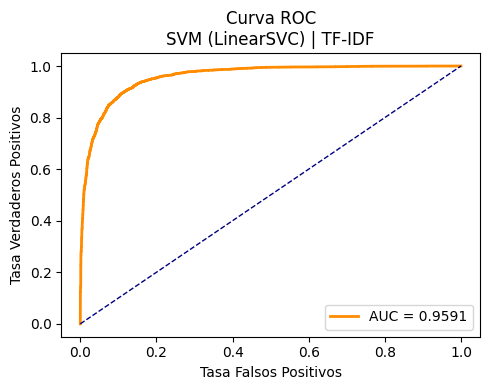


  Modelo     : Random Forest
  Vectorizer : TF-IDF
  Accuracy   : 0.8541  |  AUC-ROC: 0.9319

  Classification Report:
              precision    recall  f1-score   support

    Negativo       0.85      0.85      0.85      4940
    Positivo       0.86      0.85      0.85      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



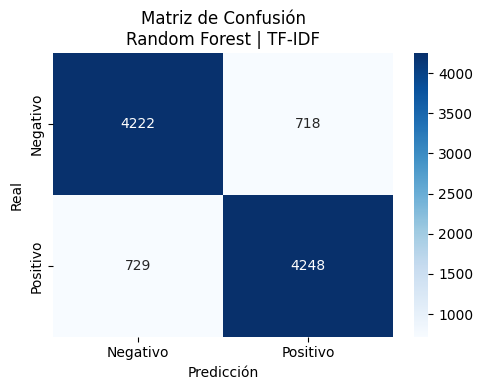

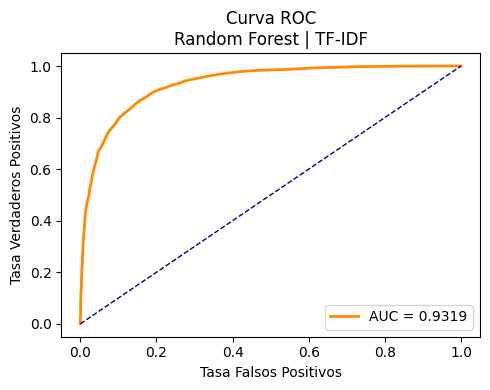


  Modelo     : kNN (k=5)
  Vectorizer : TF-IDF
  Accuracy   : 0.7587  |  AUC-ROC: 0.8291

  Classification Report:
              precision    recall  f1-score   support

    Negativo       0.80      0.69      0.74      4940
    Positivo       0.73      0.83      0.77      4977

    accuracy                           0.76      9917
   macro avg       0.76      0.76      0.76      9917
weighted avg       0.76      0.76      0.76      9917



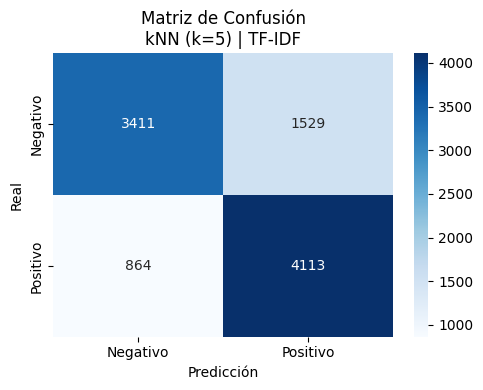

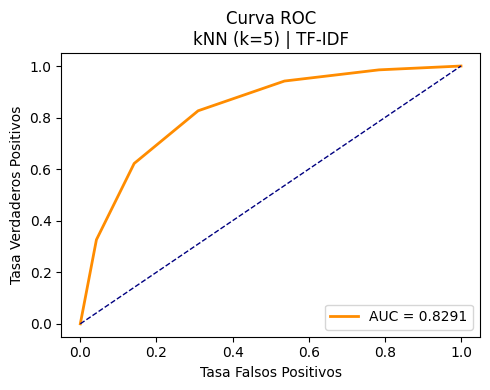


  Modelo     : Logistic Regression
  Vectorizer : TF-IDF
  Accuracy   : 0.8946  |  AUC-ROC: 0.9606

  Classification Report:
              precision    recall  f1-score   support

    Negativo       0.90      0.88      0.89      4940
    Positivo       0.89      0.91      0.90      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



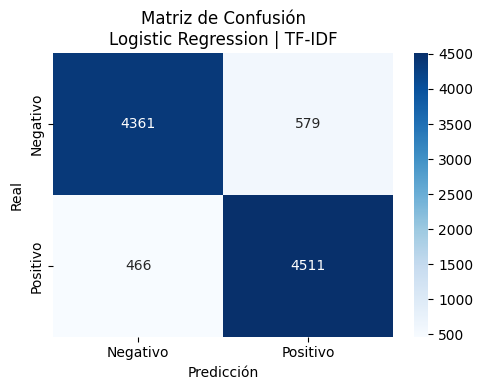

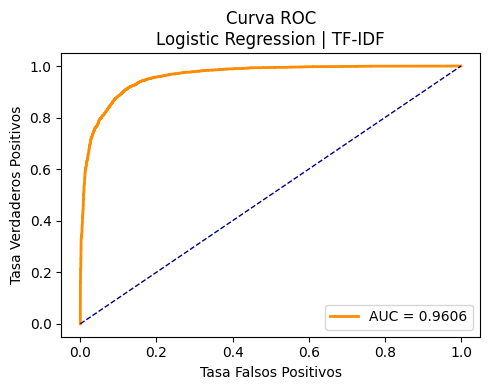

In [9]:
# 6. Vectorizadores
vectorizers = {
    'BoW (CountVectorizer)': CountVectorizer(max_features=10000),
    'TF-IDF'               : TfidfVectorizer(max_features=10000,
                                             ngram_range=(1, 2))
}

# 7. Clasificadores
classifiers = {
    'Multinomial NB'      : MultinomialNB(),
    'SVM (LinearSVC)'     : CalibratedClassifierCV(LinearSVC(max_iter=2000)),
    'Random Forest'       : RandomForestClassifier(n_estimators=100,
                                                   random_state=42,
                                                   n_jobs=-1),
    'kNN (k=5)'           : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42)
}

results_list = []

for vec_name, vectorizer in vectorizers.items():
    print(f"\n\n{'#'*62}")
    print(f"#  VECTORIZADOR: {vec_name}")
    print(f"{'#'*62}")

    # Ajustar SOLO en train (evita data leakage)
    X_train_vec = vectorizer.fit_transform(X_train_raw)
    X_test_vec  = vectorizer.transform(X_test_raw)
    print(f"   Dimensión train: {X_train_vec.shape}")
    print(f"   Dimensión test : {X_test_vec.shape}")

    for clf_name, clf in classifiers.items():
        # kNN requiere matriz densa
        Xtr = X_train_vec.toarray() if clf_name == 'kNN (k=5)' else X_train_vec
        Xte = X_test_vec.toarray()  if clf_name == 'kNN (k=5)' else X_test_vec

        result = evaluate_model(clf, Xtr, Xte, y_train, y_test,
                                clf_name, vec_name, label_names)
        results_list.append(result)





  TABLA COMPARATIVA FINAL
           Vectorizer              Modelo  Accuracy  AUC-ROC  F1 (Negativo)  F1 (Positivo)  F1 Macro Avg  Precision Macro  Recall Macro
BoW (CountVectorizer) Logistic Regression    0.8721   0.9402         0.8713         0.8730        0.8721           0.8722        0.8721
BoW (CountVectorizer)     SVM (LinearSVC)    0.8573   0.9320         0.8557         0.8589        0.8573           0.8574        0.8573
BoW (CountVectorizer)       Random Forest    0.8483   0.9244         0.8484         0.8483        0.8483           0.8484        0.8484
BoW (CountVectorizer)      Multinomial NB    0.8485   0.9160         0.8501         0.8470        0.8485           0.8488        0.8486
BoW (CountVectorizer)           kNN (k=5)    0.6504   0.6967         0.6476         0.6531        0.6504           0.6504        0.6504
               TF-IDF Logistic Regression    0.8946   0.9606         0.8930         0.8962        0.8946           0.8949        0.8946
               TF-ID

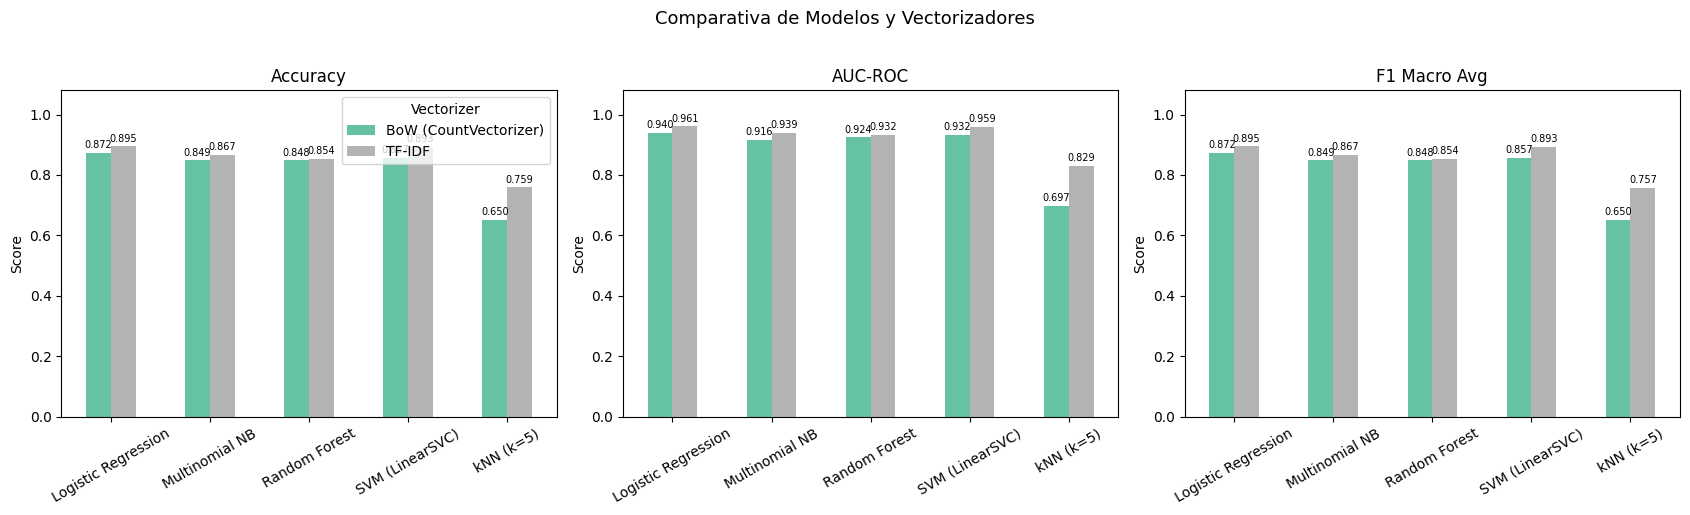

In [10]:
# 8. Tabla resumen final
print("\n\n" + "="*72)
print("  TABLA COMPARATIVA FINAL")
print("="*72)
results_df = pd.DataFrame(results_list)
results_df.sort_values(['Vectorizer','AUC-ROC'], ascending=[True,False],
                        inplace=True)
results_df.reset_index(drop=True, inplace=True)
print(results_df.to_string(index=False))

# 9. Gráfica comparativa final
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metric in zip(axes, ['Accuracy', 'AUC-ROC', 'F1 Macro Avg']):
    pivot = results_df.pivot(index='Modelo', columns='Vectorizer', values=metric)
    pivot.plot(kind='bar', ax=ax, colormap='Set2', rot=30,
               legend=(metric == 'Accuracy'))
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.08); ax.set_ylabel('Score'); ax.set_xlabel('')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.suptitle('Comparativa de Modelos y Vectorizadores', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


## Genera dos tablas como la siguiente, una utilizando Bag of Word y la otra utilizando TF-IDF.
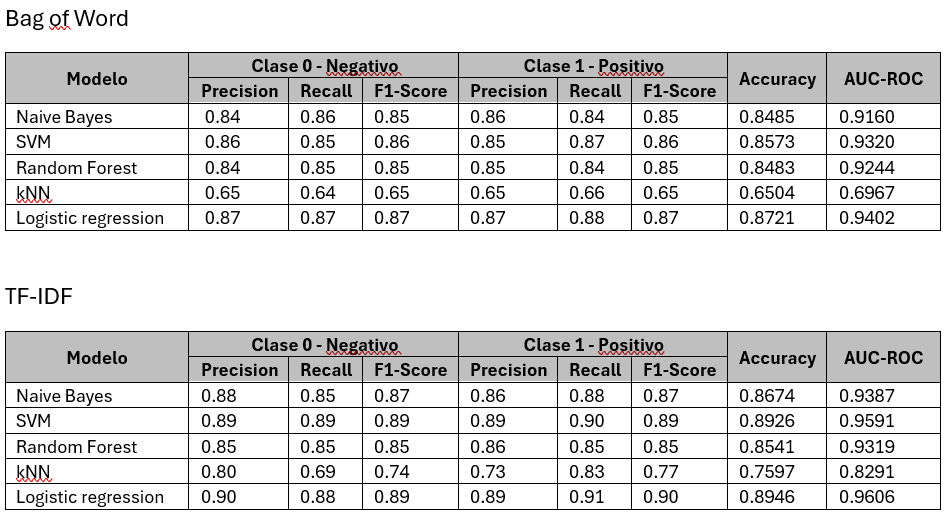

### Analiza y compara los resultados para responder lo siguiente:
•	¿Cuál fue el mejor modelo en cada una de las tablas? Justifica tus respuestas en base a las métricas obtenidas.

Mejor Modelo Bag of Word -> Logistic Regression
Se obtuvieron las mejores metricas para ambas clases,  indica que clasifica correctamente más instancias, también tiene la mejor capacidad discriminativa entre clases positiva y negativa

Mejor Modelo TF-IDF -> Logistic Regression
Se obtuvieron las mejores metricas para ambas clases,  El AUC-ROC de 0.9606 indica la mejor separación entre clases diferenciando entre clases positivas y negativas.

•	¿En qué estrategia funcionaron mejor los algoritmos de clasificación, en Bag of Words o en TF-IDF?

Los algoritmos de clasificación funcionaron de mejor manera en TF-IDF esta técnica permitió que todos los modelos incrementaran sus métricas en comparación con Bag of Words, debido a que TF-IDF no solo cuenta palabras sino que jerarquiza su importancia semántica, reduce el ruido de términos irrelevantes y facilita una mejor clasificación general.
